# Задание IV. Поиск аномалий — notebook для варианта 7

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"


## Шаг 1. Загрузка данных

В файле:
- `label = 0` — нормальный объект, то есть цифра **0**;
- `label = 6` — редкий объект, который считаем **аномалией**.

Для модели мы будем использовать только пиксели, а `label` сохраним отдельно для проверки качества уже после обучения.


In [2]:
df = pd.read_csv("mnist_small.csv")

print("Размер таблицы:", df.shape)
print("Распределение меток:")
print(df["label"].value_counts().sort_index())

X = df.drop(columns=["label"]).to_numpy(dtype=np.float32)
y = (df["label"].to_numpy() == 6).astype(int)  # 1 = аномалия (шестерка), 0 = норма (ноль)

print("\nМатрица признаков X:", X.shape)
print("Доля аномалий:", y.mean().round(4))


Размер таблицы: (5999, 785)
Распределение меток:
label
0    5923
6      76
Name: count, dtype: int64

Матрица признаков X: (5999, 784)
Доля аномалий: 0.0127


## Визуально посмотрим на несколько примеров

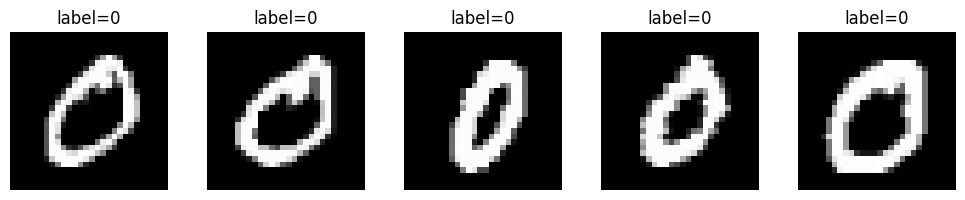

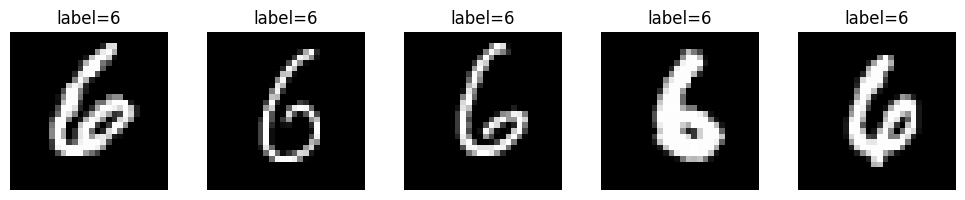

In [3]:
def show_examples(df, digit, n=5):
    idx = df.index[df["label"] == digit][:n]
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for ax, i in zip(axes, idx):
        image = df.drop(columns=["label"]).iloc[i].to_numpy().reshape(28, 28)
        ax.imshow(image)
        ax.set_title(f"label={digit}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(df, digit=0, n=5)
show_examples(df, digit=6, n=5)


## Шаг 2. Предобработка

In [4]:
# 1) Удаление константных признаков
vt = VarianceThreshold()
X_vt = vt.fit_transform(X)

# 2) Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vt)

# 3) PCA
pca = PCA(n_components=0.90, random_state=42) # 90% доля дисперсии которую нужно покрыть
X_pca = pca.fit_transform(X_scaled).astype(np.float32)

print(f"Удалено константных признаков: {X.shape[1] - X_vt.shape[1]}")
print(f"Суммарная объясненная дисперсия первых {pca.n_components_} компонент:", round(pca.explained_variance_ratio_.sum(), 4))


Удалено константных признаков: 212
Суммарная объясненная дисперсия первых 130 компонент: 0.9011


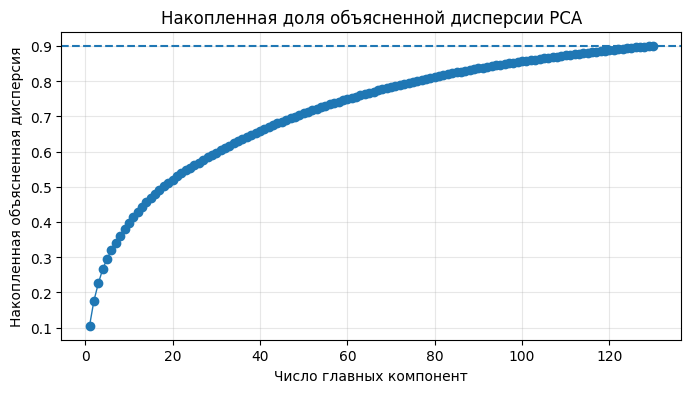

In [5]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", linewidth=1)
plt.axhline(0.9, linestyle="--")
plt.xlabel("Число главных компонент")
plt.ylabel("Накопленная объясненная дисперсия")
plt.title("Накопленная доля объясненной дисперсии PCA")
plt.grid(True, alpha=0.3)
plt.show()


## Шаг 3. Обучение LOF

In [6]:
lof = LocalOutlierFactor(
    n_neighbors=75,
    metric="euclidean",
    algorithm="brute"
)

y_pred = lof.fit_predict(X_pca)
anomaly_scores = -lof.negative_outlier_factor_

print("Минимальный score:", float(anomaly_scores.min()))
print("Максимальный score:", float(anomaly_scores.max()))
print("Средний score:", float(anomaly_scores.mean()))


Минимальный score: 0.9673547148704529
Максимальный score: 16.06572723388672
Средний score: 1.1726332902908325


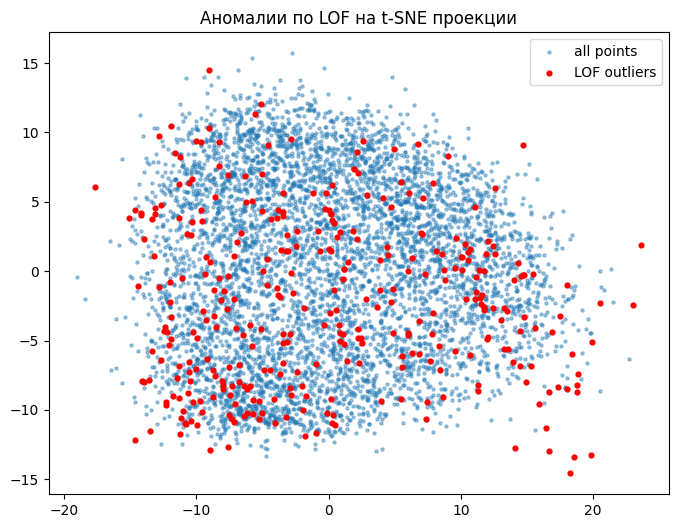

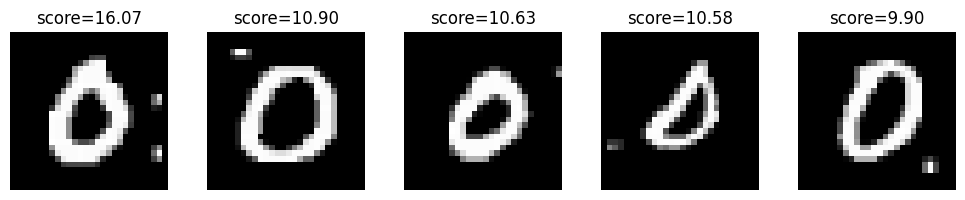

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4, label="all points")
plt.scatter(X_pca[y_pred == -1, 0], X_pca[y_pred == -1, 1], s=12, color="red", label="LOF outliers")
plt.legend()
plt.title("Аномалии по LOF на t-SNE проекции")
plt.show()

# plt.hist(anomaly_scores, bins=50)

def show_anomaly(indices, n=5):
    idx = indices[:n]
    
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    axes = np.atleast_1d(axes)

    for ax, i in zip(axes, idx):
        image = X[i].reshape(28, 28)
        ax.imshow(image, cmap='gray')
        ax.set_title(f"score={anomaly_scores[i]:.2f}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


idx = np.argsort(anomaly_scores)[-20:][::-1]
show_anomaly(idx, n=5)

## Шаг 4. ROC-кривая и EER

In [8]:
def compute_eer(y_true, score):
    """
    FPR - доля нормальных объектов, ошибочно помеченных как аномалии - отношение ошибочно названных к сумме ошибочно и нормальных
    TPR — доля найденных аномалий - отношение аномалий к сумме аномалий и пропущенных аномалий
    FNR - доля пропущенных аномалий
    """
    FPR, TPR, thresholds = roc_curve(y_true, score)
    FNR = 1 - TPR
    idx = np.argmin(np.abs(FPR - FNR)) # минимальный индекс общей ошибки системы
    EER = (FPR[idx] + FNR[idx]) / 2 # общая ошибка системы
    threshold = thresholds[idx] # порог при лучшей найденной ошибке системы
    return FPR, TPR, thresholds, FNR, idx, EER, threshold

FPR, TPR, thresholds, FNR, EER_idx, EER_value, EER_threshold = compute_eer(y, anomaly_scores)
auc = roc_auc_score(y, anomaly_scores)

print(f"AUC = {auc:.4f}")
print(f"EER = {EER_value:.4f}")
print(f"Порог в точке EER = {EER_threshold:.4f}")


AUC = 0.9539
EER = 0.0932
Порог в точке EER = 1.3164


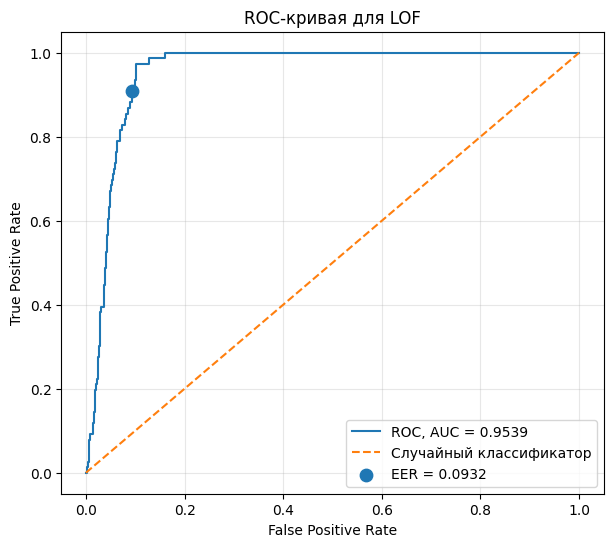

In [9]:
plt.figure(figsize=(7, 6))
plt.plot(FPR, TPR, label=f"ROC, AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Случайный классификатор")
plt.scatter(
    FPR[EER_idx],
    TPR[EER_idx],
    s=80,
    label=f"EER = {EER_value:.4f}"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая для LOF")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Интерпретация результата

In [10]:
pred_eer = (anomaly_scores >= EER_threshold).astype(int)
cm = confusion_matrix(y, pred_eer)

cm_df = pd.DataFrame(
    cm,
    index=["Истина: 0 (норма)", "Истина: 6 (аномалия)"],
    columns=["Прогноз: норма", "Прогноз: аномалия"]
)

cm_df


,Прогноз: норма,Прогноз: аномалия
Истина: 0 (норма),5364,559
Истина: 6 (аномалия),7,69


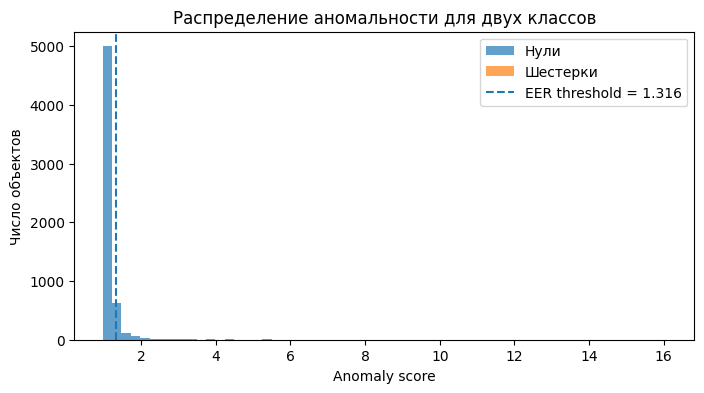

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(anomaly_scores[y == 0], bins=60, alpha=0.7, label="Нули")
plt.hist(anomaly_scores[y == 1], bins=40, alpha=0.7, label="Шестерки")
plt.axvline(EER_threshold, linestyle="--", label=f"EER threshold = {EER_threshold:.3f}")
plt.xlabel("Anomaly score")
plt.ylabel("Число объектов")
plt.title("Распределение аномальности для двух классов")
plt.legend()
plt.show()


## Шаг 5. Четыре требуемых изображения

По заданию нужно вывести:  
- самый типичный **0** — `true negative` с минимальной аномальностью;
- самая аномальная **6** — `true positive` с максимальной аномальностью;
- самый нетипичный **0** — `false positive` с максимальной аномальностью;
- самая неаномальная **6** — `false negative` с минимальной аномальностью.

Ниже выбираем индексы строго по этим определениям.


In [12]:
tn_idx = np.where((y == 0) & (pred_eer == 0))[0]
tp_idx = np.where((y == 1) & (pred_eer == 1))[0]
fp_idx = np.where((y == 0) & (pred_eer == 1))[0]
fn_idx = np.where((y == 1) & (pred_eer == 0))[0]

best_tn = tn_idx[np.argmin(anomaly_scores[tn_idx])] if len(tn_idx) else None
best_tp = tp_idx[np.argmax(anomaly_scores[tp_idx])] if len(tp_idx) else None
best_fp = fp_idx[np.argmax(anomaly_scores[fp_idx])] if len(fp_idx) else None
best_fn = fn_idx[np.argmin(anomaly_scores[fn_idx])] if len(fn_idx) else None

selected = {
    "TN: самый типичный 0": best_tn,
    "TP: самая аномальная 6": best_tp,
    "FP: самый нетипичный 0": best_fp,
    "FN: самая неаномальная 6": best_fn,
}

selected


{'TN: самый типичный 0': np.int64(5607),
 'TP: самая аномальная 6': np.int64(5974),
 'FP: самый нетипичный 0': np.int64(43),
 'FN: самая неаномальная 6': np.int64(5971)}

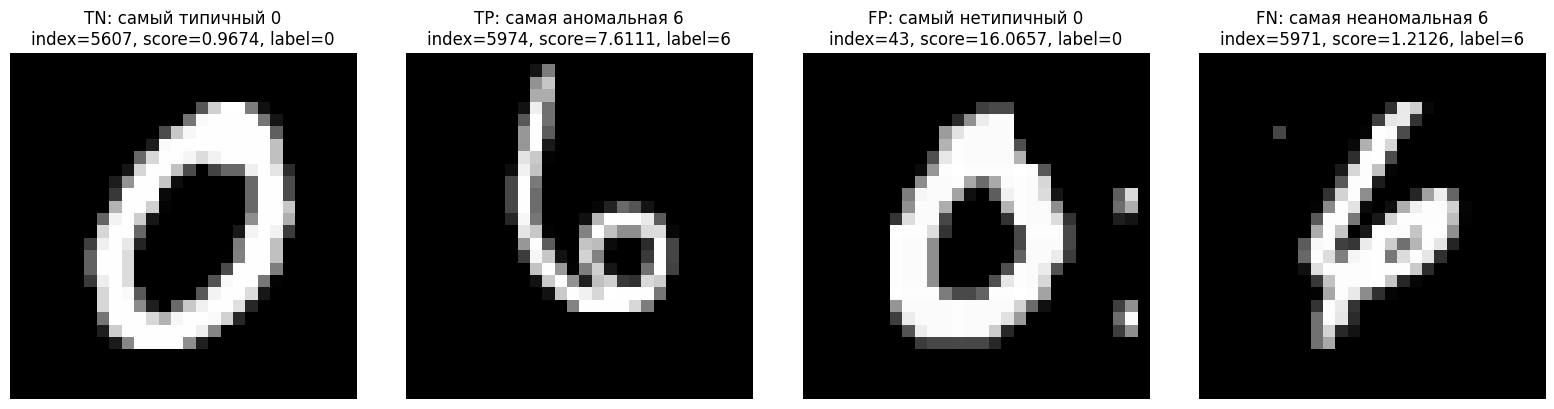

In [13]:
def show_digit_by_index(index, title):
    image = X[index].reshape(28, 28)
    plt.imshow(image)
    plt.title(f"{title}\nindex={index}, score={anomaly_scores[index]:.4f}, label={df.loc[index, 'label']}")
    plt.axis("off")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plt.sca(axes[0])
show_digit_by_index(best_tn, "TN: самый типичный 0")

plt.sca(axes[1])
show_digit_by_index(best_tp, "TP: самая аномальная 6")

plt.sca(axes[2])
show_digit_by_index(best_fp, "FP: самый нетипичный 0")

plt.sca(axes[3])
show_digit_by_index(best_fn, "FN: самая неаномальная 6")

plt.tight_layout()
plt.show()
